## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1: jumlah keuangan metode pembayaran apa saja yang lebih tinggi dan lebih rendah dibanding jumlah rata-rata sebesar 10% di dalam periode tahun 2021-2025 di dalam bidang keluaran (tidak termasuk gaji)

- **Pertanyaan 2: jumlah keuangan kategori apa saja yang lebih tinggi dan lebih rendah dibanding jumlah rata-rata sebesar 10% di dalam periode tahun 2021-2025 di dalam bidang keluaran (tidak termasuk gaji)

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# 1. LOAD DATASET
filename = 'data_v8.csv'
df = pd.read_csv(filename)
df.head()

,user_id,date,amount,type,category,subcategory,payment_method,description
0,USER_007,2022-02-25,27500.0,expense,Food,warung,cash,Pembayaran warung
1,USER_016,2025-04-14,39000.0,expense,Bills,internet,e-wallet,Pembayaran internet
2,USER_017,2025-02-18,64500.0,expense,Food,fast food,cash,Pembayaran fast food
3,USER_009,2024-06-16,48500.0,expense,Bills,internet,e-wallet,NaN
4,USER_015,2024-07-04,43000.0,expense,Entertainment,game,debit,Pembayaran game


**Insight:** (Opsional)
- tidak ada

### Assessing Data

#### Identifying ... problem

In [3]:
print("--- INFO DATASET AWAL ---")
print(f"Total baris: {len(df):,}")
print(f"Total duplicates: {df.duplicated().sum():,}")
print("\nTotal Missing Values per Kolom:")
print(df.isnull().sum())

--- INFO DATASET AWAL ---
Total baris: 134,565
Total duplicates: 13,281

Total Missing Values per Kolom:
user_id              0
date                 0
amount            4520
type                 0
category             0
subcategory       4517
payment_method    4399
description       4525
dtype: int64


**Steps to Take:**
- terdapat duplikat dan nilai kosong oleh karena itu perlu dibersihkan
- kemungkinan format data atau tipe teks yang salah

**Insight:** (Opsional)
- terdapat duplikat dan nilai kosong oleh karena itu perlu dibersihkan
- kemungkinan format data atau tipe teks yang salah

[link text](https://)### Cleaning Data



#### Fixing ... problem

In [4]:
# 1. CLEANING NOISE

# A. Drop Duplicates
df_clean = df.drop_duplicates()

# B. Drop Missing Values
df_clean = df_clean.dropna()

print("--- SETELAH CLEANING NOISE ---")
print(f"Total baris tersisa: {len(df_clean):,}")
print(f"Sisa missing values: {df_clean.isnull().sum().sum()}")
print(f"Sisa duplicates: {df_clean.duplicated().sum()}")

--- SETELAH CLEANING NOISE ---
Total baris tersisa: 111,480
Sisa missing values: 0
Sisa duplicates: 0


In [5]:
# 2. FORMATTING TIPE DATA & TEKS

# A. Tipe Data
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['amount'] = df_clean['amount'].astype(int)

# B. Standardisasi Teks (str.lower, str.title, str.strip)
text_columns = ['type', 'category', 'subcategory', 'payment_method']

for col in text_columns:
    if col == 'category':
        # Kategori pakai Title Case (Misal: Fast Food)
        df_clean[col] = df_clean[col].astype(str).str.title().str.strip()
    else:
        # Sisanya huruf kecil semua (lowercase)
        df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()

print("--- TIPE DATA SETELAH DIPERBAIKI ---")
print(df_clean.dtypes)

--- TIPE DATA SETELAH DIPERBAIKI ---
user_id                   object
date              datetime64[ns]
amount                     int64
type                      object
category                  object
subcategory               object
payment_method            object
description               object
dtype: object


In [6]:
# 3. SORTING & EXPORT

# Mengurutkan ulang karena sebelumnya data sempat diacak saat inject noise
df_clean = df_clean.sort_values(by=['user_id', 'date']).reset_index(drop=True)

# Mengecek apakah ada nilai amount yang aneh (<= 0)
invalid_amounts = df_clean[df_clean['amount'] <= 0]
if not invalid_amounts.empty:
    print(f"Peringatan: Ditemukan {len(invalid_amounts)} baris dengan amount <= 0. Baris ini akan didrop.")
    df_clean = df_clean[df_clean['amount'] > 0]

# Export ke CSV baru
cleaned_filename = 'cleaned_data_v8.csv'
df_clean.to_csv(cleaned_filename, index=False)

print(f"\n✅ Proses Wrangling Selesai!")
print(f"Data bersih berhasil disimpan ke: '{cleaned_filename}'")
print(f"Total baris akhir: {len(df_clean):,}")

# Menampilkan cuplikan data bersih
df_clean.head()


✅ Proses Wrangling Selesai!
Data bersih berhasil disimpan ke: 'cleaned_data_v8.csv'
Total baris akhir: 111,480


,user_id,date,amount,type,category,subcategory,payment_method,description
0,USER_001,2021-01-01,5000000,income,Salary,gaji bulanan,debit,Pembayaran gaji bulanan
1,USER_001,2021-01-01,14500,expense,Others,donasi,debit,Pembayaran donasi
2,USER_001,2021-01-01,79000,expense,Food,fast food,e-wallet,Pembayaran fast food
3,USER_001,2021-01-01,50000,expense,Bills,pulsa,debit,Pembayaran pulsa
4,USER_001,2021-01-02,10000,expense,Food,kopi,cash,Pembayaran kopi


**Insight:** (Opsional)
- tidak ada

### Feature engineering



In [7]:
#hari kerja dan hari libur
df=pd.read_csv('cleaned_data_v8.csv')

indo_holidays=holidays.ID(years=[2020,2021,2022,2023,2024,2024,2025,2026])

df["date"]=pd.to_datetime(df["date"])
df["holiday"]=df["date"].dt.date.isin(indo_holidays)

df["working_day"]=(
    (df["date"].dt.weekday<5)&
    (~df["holiday"])
)

df["holiday_name"]=df["date"].dt.date.map(indo_holidays)
df.to_csv('cleaned_data_v8_work_day.csv',index=False)

In [8]:
#one-hot encoding
categorical_cols=[
    "type",
    "category",
    "subcategory",
    "payment_method"
]

df_encoded=pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=False
)

df_encoded["holiday"]=df_encoded["holiday"].astype(int)
df_encoded["working_day"]=df_encoded["working_day"].astype(int)

df_encoded.to_csv('cleaned_data_v8_encoded.csv',index=False)

### Cleaning Data



## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
df=pd.read_csv('cleaned_data_v8.csv')
df.head()

,user_id,date,amount,type,category,subcategory,payment_method,description
0,USER_001,2021-01-01,5000000,income,Salary,gaji bulanan,debit,Pembayaran gaji bulanan
1,USER_001,2021-01-01,14500,expense,Others,donasi,debit,Pembayaran donasi
2,USER_001,2021-01-01,79000,expense,Food,fast food,e-wallet,Pembayaran fast food
3,USER_001,2021-01-01,50000,expense,Bills,pulsa,debit,Pembayaran pulsa
4,USER_001,2021-01-02,10000,expense,Food,kopi,cash,Pembayaran kopi


In [10]:
df=df[df['type']=="expense"]
df.head()

,user_id,date,amount,type,category,subcategory,payment_method,description
1,USER_001,2021-01-01,14500,expense,Others,donasi,debit,Pembayaran donasi
2,USER_001,2021-01-01,79000,expense,Food,fast food,e-wallet,Pembayaran fast food
3,USER_001,2021-01-01,50000,expense,Bills,pulsa,debit,Pembayaran pulsa
4,USER_001,2021-01-02,10000,expense,Food,kopi,cash,Pembayaran kopi
5,USER_001,2021-01-02,120000,expense,Shopping,minimarket,cash,Pembayaran minimarket


In [11]:
print(f"unique payment methods: {df['payment_method'].unique()}")
print(f"unique categories {df['category'].unique()}")

unique payment methods: ['debit' 'e-wallet' 'cash']
unique categories ['Others' 'Food' 'Bills' 'Shopping' 'Transport' 'Entertainment']


In [12]:
payment_method_avg=df.groupby('payment_method')['amount'].mean().reset_index()
category_avg=df.groupby('category')['amount'].mean().reset_index()
print(f"{payment_method_avg} \n{category_avg}")

  payment_method        amount
0           cash  45725.955130
1          debit  40253.450324
2       e-wallet  46018.012099 
        category        amount
0          Bills  57629.086996
1  Entertainment  54954.136584
2           Food  51453.798813
3         Others  39238.865575
4       Shopping  98249.282700
5      Transport  18519.142199


**Insight:** (Opsional)
- untuk semua pertanyaan terkonfirmasi terdapat korelasi antara semua variabel yang ingin dianalisis

## Visualization & Explanatory Analysis

In [13]:
#definisi fungsi untuk visualisasi dan analisis
def analyze(df, features, target_feature, percent_breakpoint=5):
  target_feature_average=df[target_feature].mean()
  for feature in features:
    summary=df.groupby(feature)[target_feature].mean().reset_index()
    summary['diff']=((summary[target_feature]-target_feature_average)/target_feature_average)*100
    summary['effect']=np.where(summary['diff']>=percent_breakpoint,'increase',
                      np.where(summary['diff']<=(-percent_breakpoint),'decrease',
                      'irrelevant'))
    print(summary,"\n")
  return

def plot_histo(target_feature, features):
  target_feature_average=df[target_feature].mean()
  plt.figure(figsize=(12,15))

  for i,feature in enumerate(features,1):
    plt.subplot(3,2,i)
    grouped_df=df.groupby(feature)[target_feature].mean().reset_index()
    plt.bar(grouped_df[feature],grouped_df[target_feature])
    plt.title(f'affect of {feature} on {target_feature}')
    plt.xlabel(feature)
    plt.axhline(target_feature_average,color='red',linestyle='--',label='average')
    plt.ylabel(f'average {target_feature}')
    plt.xticks(rotation=45)
    plt.legend()

  plt.tight_layout()
  plt.show()

def plot_reg(features, target_feature):
  plt.figure(figsize=(12,10))
  for i,feature in enumerate(features,1):
    plt.subplot(3,2,i)
    sns.regplot(data=df,x=feature,y=target_feature,scatter_kws={'alpha':0.3})
    plt.title(f"regplot korelasi {feature} dan {target_feature}")
  plt.tight_layout()
  plt.show()

### Pertanyaan 1:

In [14]:
#lihat faktor yang relevan
analyze(df,['payment_method'],'amount',10)

  payment_method        amount       diff      effect
0           cash  45725.955130   2.164975  irrelevant
1          debit  40253.450324 -10.062179    decrease
2       e-wallet  46018.012099   2.817515  irrelevant 



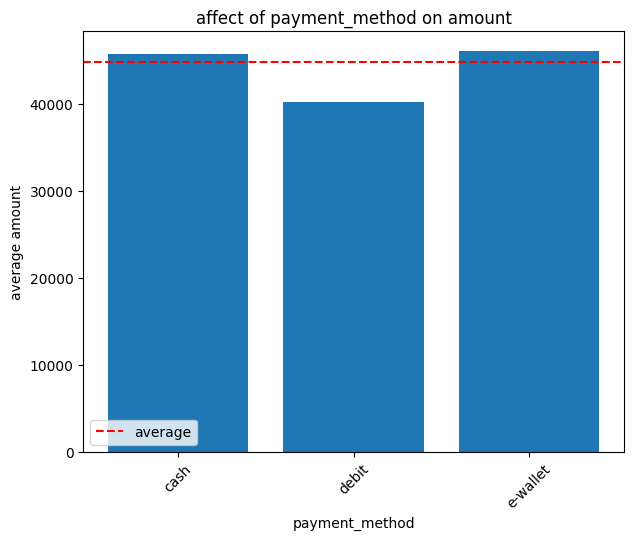

In [15]:
#visualisasi
plot_histo('amount',['payment_method'])

### Pertanyaan 2:

In [16]:
#lihat faktor yang relevan
analyze(df,['category'],'amount',10)

        category        amount        diff    effect
0          Bills  57629.086996   28.760006  increase
1  Entertainment  54954.136584   22.783395  increase
2           Food  51453.798813   14.962630  increase
3         Others  39238.865575  -12.329054  decrease
4       Shopping  98249.282700  119.517241  increase
5      Transport  18519.142199  -58.622894  decrease 



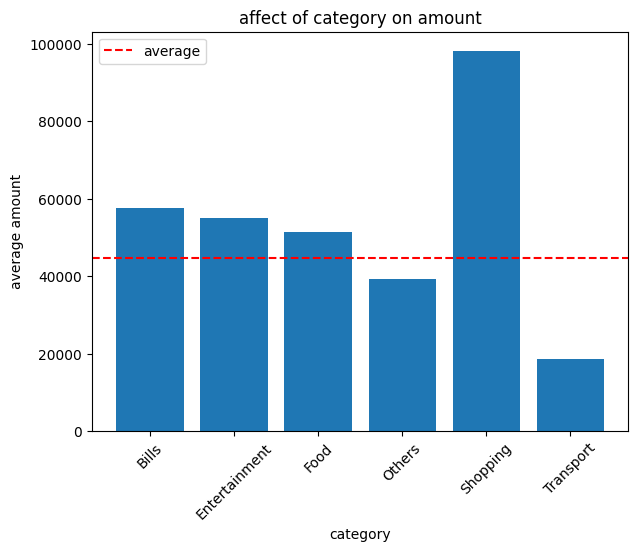

In [17]:
#visualisasi
plot_histo('amount',['category'])

**Insight:** (Opsional)
- tidak ada karena akan dijelaskan di dalam conclusion dan reccomendation


## Analisis Lanjutan (Opsional)

In [18]:
#semua analisis sudah dilakukan pada tahap "visualization and explanation"

# A/B testing

periksa apakah kesimpulan benar pada variabel yang jauh dari rata-rata atau ada perbedaan signifikan (metode pembayaran debit, kategori shopping dan kategori transport)

In [19]:
import pandas as pd
from scipy.stats import ttest_ind

df=pd.read_csv('cleaned_data_v8.csv')
df=df[df['category']!='Salary']
print(df.head())

alpha=0.05

    user_id        date  amount     type  category subcategory payment_method  \
1  USER_001  2021-01-01   14500  expense    Others      donasi          debit   
2  USER_001  2021-01-01   79000  expense      Food   fast food       e-wallet   
3  USER_001  2021-01-01   50000  expense     Bills       pulsa          debit   
4  USER_001  2021-01-02   10000  expense      Food        kopi           cash   
5  USER_001  2021-01-02  120000  expense  Shopping  minimarket           cash   

             description  
1      Pembayaran donasi  
2   Pembayaran fast food  
3       Pembayaran pulsa  
4        Pembayaran kopi  
5  Pembayaran minimarket  


In [20]:
df_debit=df[df['payment_method']=='debit']['amount']
df_non_debit=df[df['payment_method']!='debit']['amount']

T,P=ttest_ind(
    df_debit,
    df_non_debit,
    equal_var=False
)

print("T:",T)
print("P:",P)

if P<alpha:
    print('significant difference')
else:
    print('no significant difference')

T: -22.504291424855335
P: 2.115604399778966e-111
significant difference


-nilai t sangat rendah berarti rata-rata debit sangat rendah

-nilai p rendah berarti data pasti relevan karena pasti tidak terjadi secara acak

-bisa simpulkan bahwa sudah benar bahwa metode pembayaran debit sangat rendah dibanding metode pembayaran lain

In [21]:
df_shopping=df[df['category']=='Shopping']['amount']
df_non_shopping=df[df['category']!='Shopping']['amount']

T,P=ttest_ind(
    df_shopping,
    df_non_shopping,
    equal_var=False
)

print("T:",T)
print("P:",P)

if P<alpha:
    print('significant difference')
else:
    print('no significant difference')

T: 126.81818357062569
P: 0.0
significant difference


-nilai t sangat tinggi berarti rata-rata debit sangat rendah

-nilai p 0 berarti data pasti relevan karena pasti tidak terjadi secara acak

-bisa simpulkan bahwa sudah benar bahwa kategori shopping sangat tinggi dibanding kategori lain

In [22]:
df_transport=df[df['category']=='Transport']['amount']
df_non_transport=df[df['category']!='Transport']['amount']

T,P=ttest_ind(
    df_transport,
    df_non_transport,
    equal_var=False
)

print("T:",T)
print("P:",P)

if P<alpha:
    print('significant difference')
else:
    print('no significant difference')

T: -242.37057043438915
P: 0.0
significant difference


-nilai t sangat rendah berarti rata-rata debit sangat rendah

-nilai p 0 berarti data pasti relevan karena pasti tidak terjadi secara acak

-bisa simpulkan bahwa sudah benar bahwa kategori transport sangat rendah dibanding kategori lain

# Conclusion & Recommendation

**Conclusion pertanyaan 1:**
Berdasarkan analisis data pengeluaran (di luar gaji) periode 2021-2025, hanya metode pembayaran debit yang memiliki nilai rata-rata pengeluaran signifikan lebih rendah, yaitu sebesar 10.06% di bawah rata-rata keseluruhan. Sementara itu, metode pembayaran cash dan e-wallet cenderung stabil dan tidak menunjukkan perbedaan yang signifikan.

**Conclusion pertanyaan 2:**
Mayoritas kategori pengeluaran memiliki jumlah rata-rata di atas batas 10% dari rata-rata keseluruhan. Kategori Shopping menjadi yang paling tinggi dengan lonjakan mencapai 119.51% di atas rata-rata, diikuti oleh Bills (+28.76%), Entertainment (+22.78%), dan Food (+14.96%). Sebaliknya, kategori Transport dan Others berada di bawah rata-rata, di mana kategori Transport menunjukkan penurunan paling tajam yaitu 58.62% di bawah rata-rata keseluruhan.

**Rekomendasi Action Item:**
- mengenai metode pembayaran debit, lebih baik untuk coba investigasi kenapa metode pembayaran debit lebih rendah dibanding metode pembayaran lain. Selain itu jika ingin meningkati meotde pembayaran debit coba kasih insentif untuk pelanggan seperti cashback, hadiah, dan lain-lain agar pelanggan lebih sering menggunakan metode pembayaran debit.
- mengenai kategori yang tinggi, lebih baik untuk mengambil keuntungan dan meningkat dengan menambahkan insentif seperti cashback dan diskon (dalam jumlah kecil) untuk semua kategori (kecuali shopping) untuk meningkat dan mempertahankan keuangan tinggi. Shopping tidak perlu karena sudah jauh lebih tinggi dan insentif diskon dan cashback hanya akan rugi karena pelanggan sudah kebiasaaan menggunakan keuangan yang tinggi untuk kategori tersebut. Jika ingin menambahkan insentif untuk shopping lebih baik investigasi pengakibat dari peningkatan dulu sebelum menambahkan insentif.
- mengenai kategori yang rendah, lebih baik melakukan investigasi kepada kenapa kategori transport sangat rendah dan tergantung dengan hasil investigasi, tambahkan insentif seperti diskon dan cashback agar lebih banyak pelanggan menggunakan pelayanan tersebut. Untuk kategori others cukup tambah insentif yang sudah dijelaskan sebelumnya.